# Exploration complète d'une base de donnée sur le covid 19

# INSPECTION

In [1]:
# Importons les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#chargeons le dataset
df = pd.read_csv("covid_19_data.csv")
df.head(20)

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
5,6,01/22/2020,Guangdong,Mainland China,1/22/2020 17:00,26.0,0.0,0.0
6,7,01/22/2020,Guangxi,Mainland China,1/22/2020 17:00,2.0,0.0,0.0
7,8,01/22/2020,Guizhou,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
8,9,01/22/2020,Hainan,Mainland China,1/22/2020 17:00,4.0,0.0,0.0
9,10,01/22/2020,Hebei,Mainland China,1/22/2020 17:00,1.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SNo              4247 non-null   int64  
 1   ObservationDate  4247 non-null   object 
 2   Province/State   2746 non-null   object 
 3   Country/Region   4247 non-null   object 
 4   Last Update      4247 non-null   object 
 5   Confirmed        4247 non-null   float64
 6   Deaths           4247 non-null   float64
 7   Recovered        4247 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 265.6+ KB


In [4]:
print("Nombre de lignes et de colonnes:", df.shape)

Nombre de lignes et de colonnes: (4247, 8)


In [5]:
# valeurs suspectes
df.loc[ : , df.columns != "SNo"].describe()


,Confirmed,Deaths,Recovered
count,4247.000000,4247.000000,4247.000000
mean,586.884624,17.530257,187.914528
std,5033.596411,190.278672,1976.388824
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000
75%,99.500000,1.000000,16.000000
max,67707.000000,2986.000000,45235.000000


In [6]:
# conversion de float en int
df["Confirmed"] = df["Confirmed"].astype(int)
df["Deaths"] = df["Deaths"].astype(int)
df["Recovered"] = df["Recovered"].astype(int)

In [7]:
print("Types de variables :\n\n", df.dtypes)


Types de variables :

 SNo                 int64
ObservationDate    object
Province/State     object
Country/Region     object
Last Update        object
Confirmed           int64
Deaths              int64
Recovered           int64
dtype: object


### renommons Last Update

In [8]:

df.rename(columns={"Last Update": "LastUpdate"}, inplace=True)

### ObservationDate  en datetime

In [9]:

df["ObservationDate"] = pd.to_datetime(df["ObservationDate"], format="%m/%d/%Y")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   SNo              4247 non-null   int64         
 1   ObservationDate  4247 non-null   datetime64[ns]
 2   Province/State   2746 non-null   object        
 3   Country/Region   4247 non-null   object        
 4   LastUpdate       4247 non-null   object        
 5   Confirmed        4247 non-null   int64         
 6   Deaths           4247 non-null   int64         
 7   Recovered        4247 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 265.6+ KB


### LastUpdate  en datetime

In [11]:
df["LastUpdate"] = pd.to_datetime(df["LastUpdate"], format="mixed", errors="coerce")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   SNo              4247 non-null   int64         
 1   ObservationDate  4247 non-null   datetime64[ns]
 2   Province/State   2746 non-null   object        
 3   Country/Region   4247 non-null   object        
 4   LastUpdate       4247 non-null   datetime64[ns]
 5   Confirmed        4247 non-null   int64         
 6   Deaths           4247 non-null   int64         
 7   Recovered        4247 non-null   int64         
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 265.6+ KB


In [13]:
df.head(20)

,SNo,ObservationDate,Province/State,Country/Region,LastUpdate,Confirmed,Deaths,Recovered
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1,0,0
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14,0,0
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6,0,0
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1,0,0
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0,0,0
5,6,2020-01-22,Guangdong,Mainland China,2020-01-22 17:00:00,26,0,0
6,7,2020-01-22,Guangxi,Mainland China,2020-01-22 17:00:00,2,0,0
7,8,2020-01-22,Guizhou,Mainland China,2020-01-22 17:00:00,1,0,0
8,9,2020-01-22,Hainan,Mainland China,2020-01-22 17:00:00,4,0,0
9,10,2020-01-22,Hebei,Mainland China,2020-01-22 17:00:00,1,0,0


# valeurs manquantes

In [14]:
df["Province/State"].fillna("Inconnue", inplace=True)

C:\Users\samba\AppData\Local\Temp\ipykernel_4968\1437032200.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Province/State"].fillna("Inconnue", inplace=True)


In [15]:
print("Valeurs manquantes après remplissage :\n", df.isnull().sum())

Valeurs manquantes après remplissage :
 SNo                0
ObservationDate    0
Province/State     0
Country/Region     0
LastUpdate         0
Confirmed          0
Deaths             0
Recovered          0
dtype: int64


##### country (distribution, boxplot, info)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   SNo              4247 non-null   int64         
 1   ObservationDate  4247 non-null   datetime64[ns]
 2   Province/State   4247 non-null   object        
 3   Country/Region   4247 non-null   object        
 4   LastUpdate       4247 non-null   datetime64[ns]
 5   Confirmed        4247 non-null   int64         
 6   Deaths           4247 non-null   int64         
 7   Recovered        4247 non-null   int64         
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 265.6+ KB


Confirmed
count     4247.000000
mean       586.884624
std       5033.596411
min          0.000000
25%          1.000000
50%          9.000000
75%         99.500000
max      67707.000000
Name: Confirmed, dtype: float64


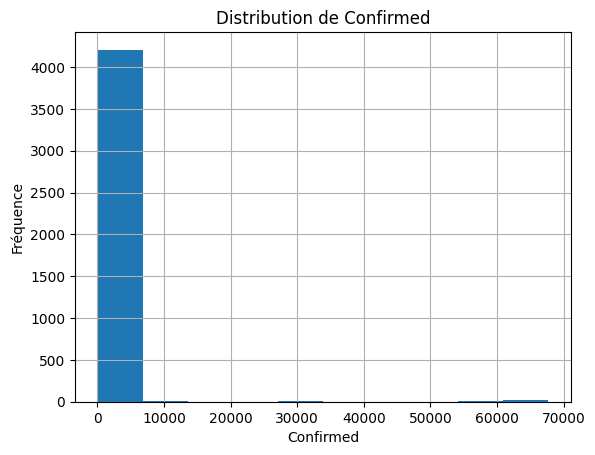

In [17]:
col = "Confirmed"


print(f"{col}")
print(df[col].describe())
    
plt.figure()
df[col].hist()
plt.title(f"Distribution de {col}")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()


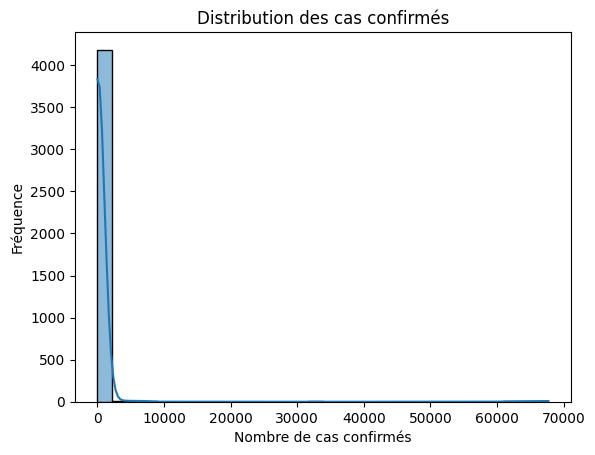

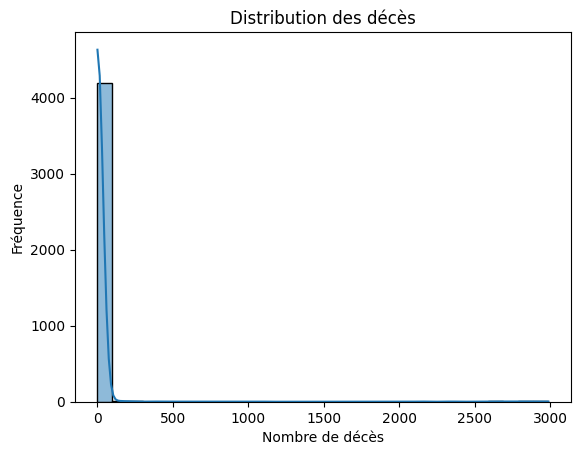

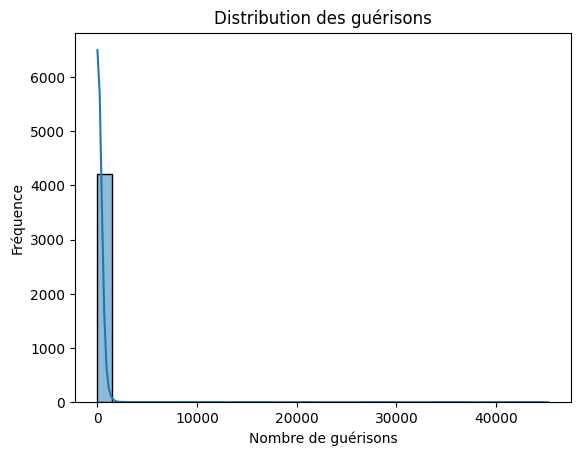

In [18]:
# Distribution de "Confirmed", "Deaths", "Recovered" avec sns.histplot
sns.histplot(data=df, x="Confirmed", bins=30, kde=True)
plt.title("Distribution des cas confirmés")
plt.xlabel("Nombre de cas confirmés")
plt.ylabel("Fréquence")
plt.show()

sns.histplot(data=df, x="Deaths", bins=30, kde=True)
plt.title("Distribution des décès")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")
plt.show()

sns.histplot(data=df, x="Recovered", bins=30, kde=True)
plt.title("Distribution des guérisons")
plt.xlabel("Nombre de guérisons")
plt.ylabel("Fréquence")
plt.show()

# plt.show()

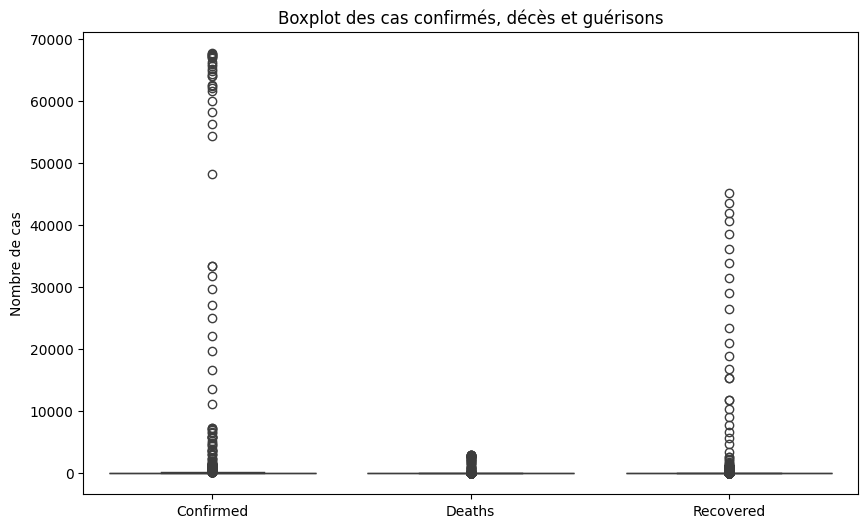

In [19]:
# boxplot pour "Confirmed", "Deaths", "Recovered"
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["Confirmed", "Deaths", "Recovered"]])
plt.title("Boxplot des cas confirmés, décès et guérisons")
plt.ylabel("Nombre de cas")
plt.show()

# aberrantes

In [20]:
def aberrant_mad(colonne, limite=3.0):
    median = colonne.median()
    mad = np.median(np.abs(colonne - median))
    modified_z_scores = 0.6745 * (colonne - median) / mad
    return np.abs(modified_z_scores) > limite

outliers_confirmed = aberrant_mad(df["Confirmed"])
outliers_deaths = aberrant_mad(df["Deaths"])
outliers_recovered = aberrant_mad(df["Recovered"])

print("Nombre de valeurs aberrantes détectées pour Confirmed:", outliers_confirmed.sum())
print("Nombre de valeurs aberrantes détectées pour Deaths:", outliers_deaths.sum())
print("Nombre de valeurs aberrantes détectées pour Recovered:", outliers_recovered.sum()) 




Nombre de valeurs aberrantes détectées pour Confirmed: 1423
Nombre de valeurs aberrantes détectées pour Deaths: 1104
Nombre de valeurs aberrantes détectées pour Recovered: 1322


In [21]:
def aberrant_mad_pays(df, colonne, limite=3.0):
    outliers = []
    for country in df["Country/Region"].unique():
        country_data = df[df["Country/Region"] == country]
        if len(country_data) > 0:
            median = country_data[colonne].median()
            mad = np.median(np.abs(country_data[colonne] - median))
            if mad > 0:
                modified_z_scores = 0.6745 * (country_data[colonne] - median) / mad
                country_outliers = country_data[np.abs(modified_z_scores) > limite].copy()
                country_outliers["MAD_score"] = modified_z_scores[np.abs(modified_z_scores) > limite]
                outliers.append(country_outliers)
    if outliers:
        return pd.concat(outliers)
    else:
        print("Aucune valeur aberrante détectée.")
        return pd.DataFrame()
    

outliers_confirmed = aberrant_mad_pays(df, "Confirmed", limite=3.0)
print(f"Aberrantes détectées pour Confirmed: {len(outliers_confirmed)}")

outliers_deaths = aberrant_mad_pays(df, "Deaths", limite=3.0)
print(f"Aberrantes détectées pour Deaths: {len(outliers_deaths)}")

outliers_recovered = aberrant_mad_pays(df, "Recovered", limite=3.0)
print(f"Aberrantes détectées pour Recovered: {len(outliers_recovered)}")

Aberrantes détectées pour Confirmed: 439


Aberrantes détectées pour Deaths: 218


Aberrantes détectées pour Recovered: 378


Country/Region 
Nombre de modalités : 111
Country/Region
Mainland China    1451
US                 783
Australia          201
Canada             133
Macau               47
Japan               47
Taiwan              47
Thailand            47
South Korea         47
Hong Kong           47
Name: count, dtype: int64


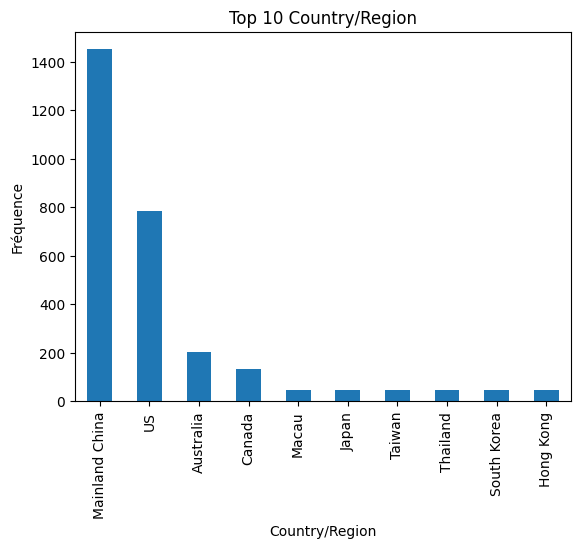

In [22]:
col = "Country/Region"


print(f"{col} ")
print("Nombre de modalités :", df[col].nunique())
print(df[col].value_counts().head(10))
    
plt.figure()
df[col].value_counts().head(10).plot(kind='bar')
plt.title(f"Top 10 {col}")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()

In [23]:

incoherences = df[df["Deaths"] > df["Confirmed"]]
print(f"Lignes où Deaths > Confirmed : {len(incoherences)}")

incoherences = df[df["Recovered"] > df["Confirmed"]]
print(f"Lignes où Recovered > Confirmed : {len(incoherences)}")

incoherences = df[(df["Deaths"] + df["Recovered"]) > df["Confirmed"]]
print(f"Lignes où Deaths + Recovered > Confirmed : {len(incoherences)}")

Lignes où Deaths > Confirmed : 0
Lignes où Recovered > Confirmed : 0
Lignes où Deaths + Recovered > Confirmed : 0


# total des cas confirmés par pays


Cas confirmés par pays
Country/Region
Mainland China    2312052
South Korea         58078
Italy               35041
Iran                30003
Others              15692
Japan                5309
France               4411
Germany              4316
Singapore            2817
US                   2660
Name: Confirmed, dtype: int64


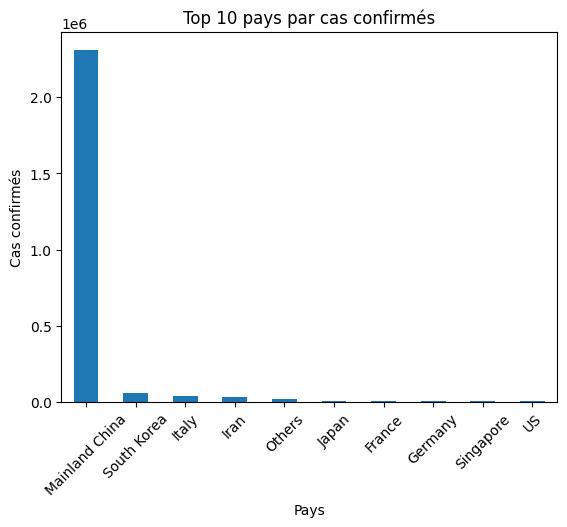

In [24]:

confirmed_by_country = df.groupby("Country/Region")["Confirmed"].sum().sort_values(ascending=False)

print("Cas confirmés par pays")
print(confirmed_by_country.head(10))

plt.figure()
confirmed_by_country.head(10).plot(kind='bar')
plt.title("Top 10 pays par cas confirmés")
plt.xlabel("Pays")
plt.ylabel("Cas confirmés")
plt.xticks(rotation=45)
plt.show()


# total des morts par pays 

Morts par pays
Country/Region
Mainland China    71199
Italy              1318
Iran               1030
South Korea         362
US                   90
Others               83
France               77
Japan                76
Hong Kong            54
Spain                38
Name: Deaths, dtype: int64


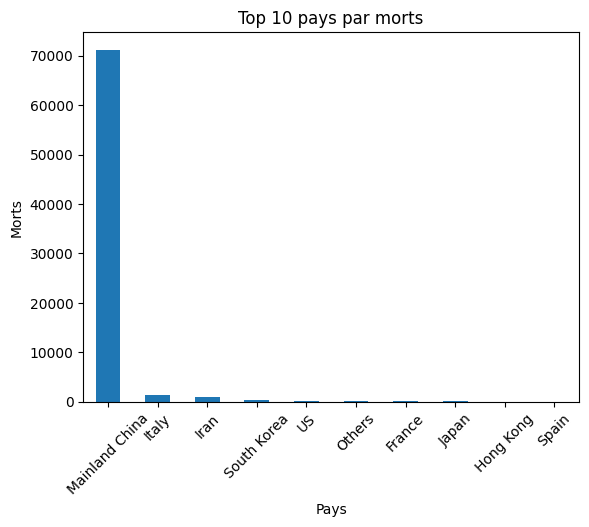

In [25]:

confirmed_by_country = df.groupby("Country/Region")["Deaths"].sum().sort_values(ascending=False)

print("Morts par pays")
print(confirmed_by_country.head(10))

plt.figure()
confirmed_by_country.head(10).plot(kind='bar')
plt.title("Top 10 pays par morts")
plt.xlabel("Pays")
plt.ylabel("Morts")
plt.xticks(rotation=45)
plt.show()

# total des guéris par pays 

Les guéris par pays
Country/Region
Mainland China    780798
Iran                7058
Italy               2961
Singapore           1324
South Korea          843
Japan                739
Thailand             662
Hong Kong            536
Malaysia             404
Vietnam              342
Name: Recovered, dtype: int64


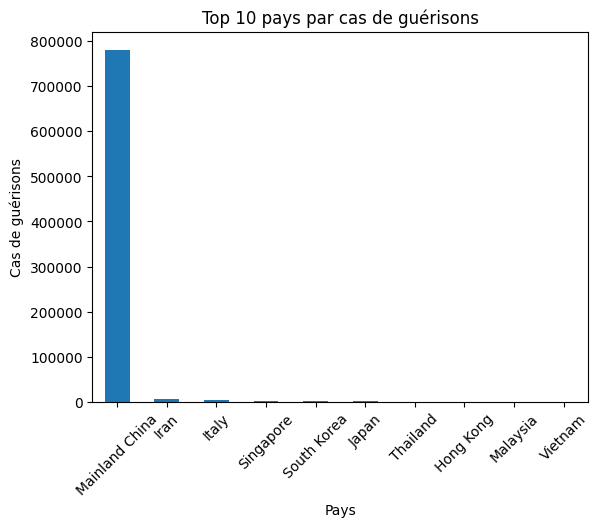

In [26]:

confirmed_by_country = df.groupby("Country/Region")["Recovered"].sum().sort_values(ascending=False)

print("Les guéris par pays")
print(confirmed_by_country.head(10))

plt.figure()
confirmed_by_country.head(10).plot(kind='bar')
plt.title("Top 10 pays par cas de guérisons")
plt.xlabel("Pays")
plt.ylabel("Cas de guérisons")
plt.xticks(rotation=45)
plt.show()

# Boxplot (distribution par pays)

<Figure size 640x480 with 0 Axes>

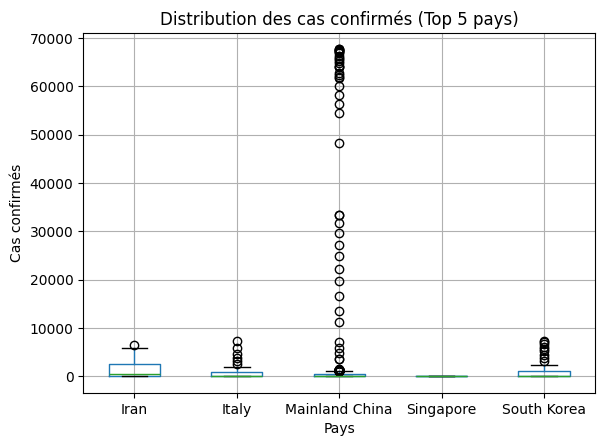

In [27]:

top_countries = confirmed_by_country.head(5).index

plt.figure()
df[df["Country/Region"].isin(top_countries)].boxplot(column="Confirmed", by="Country/Region")
plt.title("Distribution des cas confirmés (Top 5 pays)")
plt.suptitle("")
plt.xlabel("Pays")
plt.ylabel("Cas confirmés")
plt.show()


<Figure size 640x480 with 0 Axes>

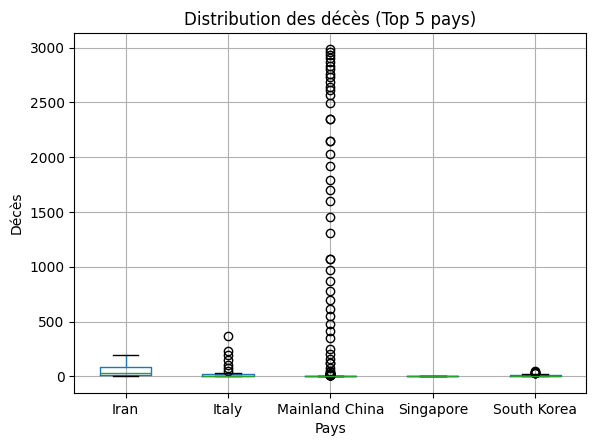


Statistiques par pays
                     mean   max  min    sum
Country/Region                             
Mainland China  49.068918  2986    0  71199
Italy           34.684211   366    0   1318
Iran            54.210526   194    2   1030
South Korea      7.702128    50    0    362
US               0.114943    17    0     90
Others           2.677419     6    0     83
France           1.711111    19    0     77
Japan            1.617021     6    0     76
Hong Kong        1.148936     3    0     54
Spain            1.027027    17    0     38


In [28]:

top_countries = confirmed_by_country.head(5).index

plt.figure()
df[df["Country/Region"].isin(top_countries)].boxplot(column="Deaths", by="Country/Region")
plt.title("Distribution des décès (Top 5 pays)")
plt.suptitle("")
plt.xlabel("Pays")
plt.ylabel("Décès")
plt.show()

stats = df.groupby("Country/Region")["Deaths"].agg(["mean", "max", "min", "sum"])
print("\nStatistiques par pays")
print(stats.sort_values("sum", ascending=False).head(10))

<Figure size 640x480 with 0 Axes>

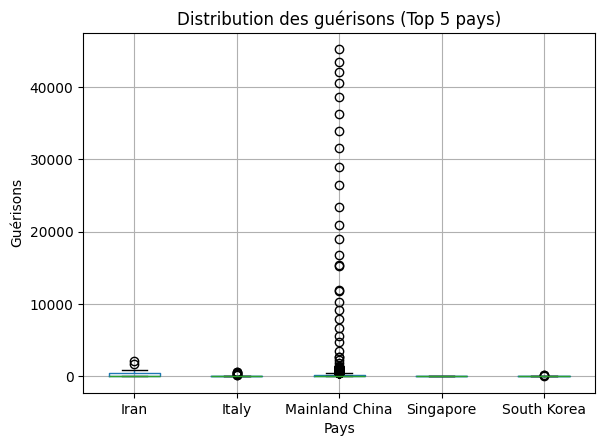


Statistiques par pays
                      mean    max  min     sum
Country/Region                                
Mainland China  538.110269  45235    0  780798
Iran            371.473684   2134    0    7058
Italy            77.921053    622    0    2961
Singapore        28.782609     78    0    1324
South Korea      17.936170    135    0     843
Japan            15.723404     76    0     739
Thailand         14.085106     31    0     662
Hong Kong        11.404255     58    0     536
Malaysia          8.977778     24    0     404
Vietnam           7.434783     16    0     342


In [29]:


top_countries = confirmed_by_country.head(5).index

plt.figure()
df[df["Country/Region"].isin(top_countries)].boxplot(column="Recovered", by="Country/Region")
plt.title("Distribution des guérisons (Top 5 pays)")
plt.suptitle("")
plt.xlabel("Pays")
plt.ylabel("Guérisons")
plt.show()

stats = df.groupby("Country/Region")["Recovered"].agg(["mean", "max", "min", "sum"])
print("\nStatistiques par pays")
print(stats.sort_values("sum", ascending=False).head(10))

In [30]:
# Statistiques par pays
stats = df.groupby("Country/Region")["Confirmed"].agg(["mean", "max", "min", "sum"])
print("\nCas confirmés par pays")
print(stats.sort_values("sum", ascending=False).head(5))

stats = df.groupby("Country/Region")["Deaths"].agg(["mean", "max", "min", "sum"])
print("\nDécès par pays")
print(stats.sort_values("sum", ascending=False).head(5))

stats = df.groupby("Country/Region")["Recovered"].agg(["mean", "max", "min", "sum"])
print("\nRétablissements par pays")
print(stats.sort_values("sum", ascending=False).head(5))


Cas confirmés par pays
                       mean    max  min      sum
Country/Region                                  
Mainland China  1593.419711  67707    0  2312052
South Korea     1235.702128   7314    1    58078
Italy            922.131579   7375    2    35041
Iran            1579.105263   6566    2    30003
Others           506.193548    706   61    15692

Décès par pays
                     mean   max  min    sum
Country/Region                             
Mainland China  49.068918  2986    0  71199
Italy           34.684211   366    0   1318
Iran            54.210526   194    2   1030
South Korea      7.702128    50    0    362
US               0.114943    17    0     90

Rétablissements par pays
                      mean    max  min     sum
Country/Region                                
Mainland China  538.110269  45235    0  780798
Iran            371.473684   2134    0    7058
Italy            77.921053    622    0    2961
Singapore        28.782609     78    0    1324
S

### nombre de cas confirmés, de morts et de guérisons et par date

In [31]:
cases_by_date = df.groupby("ObservationDate")[["Confirmed", "Deaths", "Recovered"]].sum()
print("\nCas par date")
print(cases_by_date.head(10))




Cas par date


                 Confirmed  Deaths  Recovered
ObservationDate                              
2020-01-22             555      17         28
2020-01-23             653      18         30
2020-01-24             941      26         36
2020-01-25            1438      42         39
2020-01-26            2118      56         52
2020-01-27            2927      82         61
2020-01-28            5578     131        107
2020-01-29            6165     133        126
2020-01-30            8235     171        143
2020-01-31            9925     213        222


In [32]:
# les jours avec le plus de cas
cases_by_date_desc = cases_by_date.sort_index(ascending=False)
print("Top 10 jours avec le plus de cas")
print(cases_by_date_desc.head(10))

Top 10 jours avec le plus de cas
                 Confirmed  Deaths  Recovered
ObservationDate                              
2020-03-08          109835    3803      60695
2020-03-07          105836    3558      58359
2020-03-06          101800    3460      55866
2020-03-05           97886    3348      53797
2020-03-04           95124    3254      51171
2020-03-03           92844    3160      48229
2020-03-02           90309    3085      45602
2020-03-01           88371    2996      42716
2020-02-29           86013    2941      39782
2020-02-28           84124    2872      36711


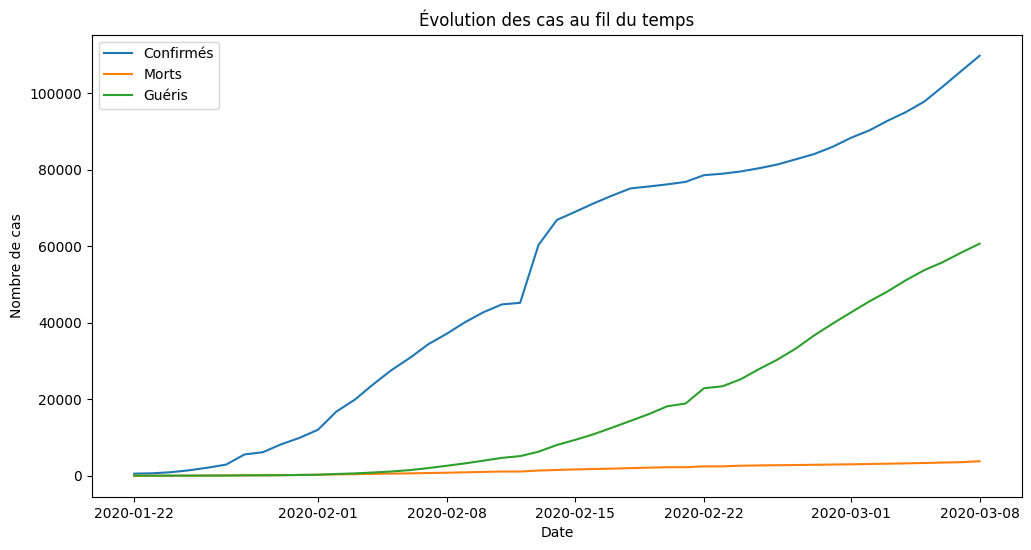

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(cases_by_date.index, cases_by_date["Confirmed"], label="Confirmés")
plt.plot(cases_by_date.index, cases_by_date["Deaths"], label="Morts")
plt.plot(cases_by_date.index, cases_by_date["Recovered"], label="Guéris")
plt.title("Évolution des cas au fil du temps")
plt.xlabel("Date")
plt.ylabel("Nombre de cas") 
plt.legend()
plt.show()


Text(0.5, 1.0, 'Matrice de corrélation')

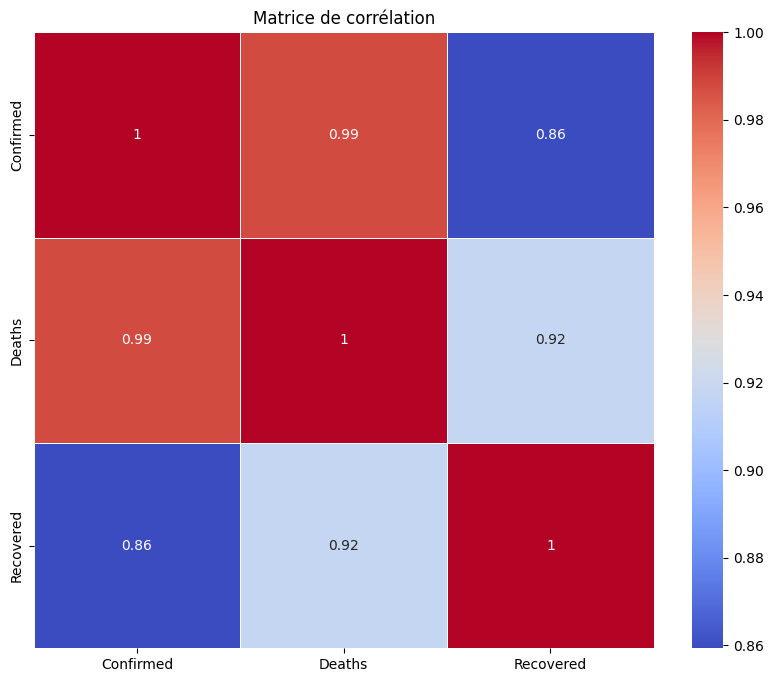

In [34]:
#matrice de corrélation avec uniquement les variables explicatives numériques sans id
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df = numerical_df.drop(columns=['SNo'])

correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matrice de corrélation")